# 04 — Quality CNN: Treino e Avaliação

Este notebook treina o modelo MobileNetV2 para classificação de qualidade de documentos e gera as visualizações de avaliação:

- **Training curves** (loss e accuracy)
- **Confusion matrix**
- **ROC curve** (multiclass)
- **Classification report**
- **Distribuição de scores por classe**

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

from src.quality.dataset import QualityDataset, train_transform, default_transform, IDX_TO_LABEL
from src.quality.model import QualityClassifier

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

LABELS_PATH = Path('../data/synthetic/labels.json')
SYNTHETIC_DIR = Path('../data/synthetic')
OUTPUT_DIR = Path('../models/quality_cnn')
RESULTS_DIR = Path('../results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: mps


## 1. Carregar Dataset e Verificar Distribuição

In [2]:
train_ds = QualityDataset(LABELS_PATH, SYNTHETIC_DIR, transform=train_transform(), split='train')
val_ds = QualityDataset(LABELS_PATH, SYNTHETIC_DIR, transform=default_transform(), split='val')
test_ds = QualityDataset(LABELS_PATH, SYNTHETIC_DIR, transform=default_transform(), split='test')

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

# Distribuição por split
from collections import Counter
for name, ds in [('Train', train_ds), ('Val', val_ds), ('Test', test_ds)]:
    counts = Counter(entry['label'] for entry in ds.samples)
    print(f'  {name}: {dict(counts)}')

Train: 2652, Val: 568, Test: 571
  Train: {'ready': 481, 'marginal': 809, 'not_ready': 1362}
  Val: {'ready': 103, 'marginal': 173, 'not_ready': 292}
  Test: {'ready': 104, 'marginal': 174, 'not_ready': 293}


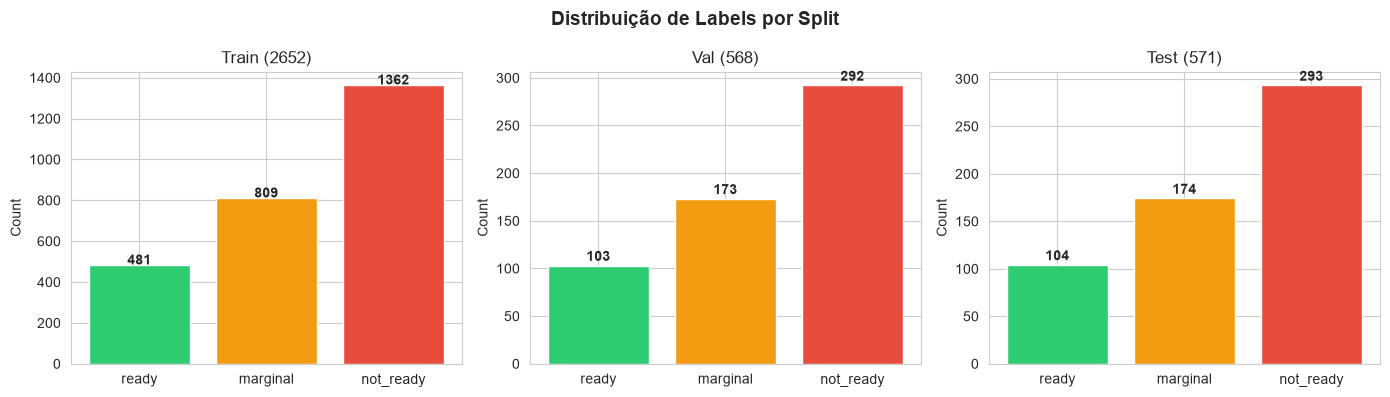

In [3]:
# Visualizar distribuição
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, ds) in zip(axes, [('Train', train_ds), ('Val', val_ds), ('Test', test_ds)]):
    counts = Counter(entry['label'] for entry in ds.samples)
    labels = ['ready', 'marginal', 'not_ready']
    values = [counts[l] for l in labels]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    ax.bar(labels, values, color=colors)
    ax.set_title(f'{name} ({sum(values)})')
    ax.set_ylabel('Count')
    for i, v in enumerate(values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribuição de Labels por Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_label_distribution.png', bbox_inches='tight')
plt.show()

## 2. Treinar o Modelo

In [4]:
from src.quality.train import train_one_epoch, evaluate
import torch.nn as nn
import time

BATCH_SIZE = 32
EPOCHS_FROZEN = 5
EPOCHS_FINETUNE = 10
LR_FROZEN = 1e-3
LR_FINETUNE = 1e-4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = QualityClassifier(num_classes=3, pretrained=True).to(device)

# Class weights
label_counts = Counter(entry['label'] for entry in train_ds.samples)
total = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (3 * label_counts[IDX_TO_LABEL[i]]) for i in range(3)],
    dtype=torch.float32
).to(device)
print(f'Class weights: {class_weights.cpu().tolist()}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/brunokohn/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


  0%|                                              | 0.00/13.6M [00:00<?, ?B/s]

  5%|█▋                                    | 640k/13.6M [00:00<00:02, 6.11MB/s]

 11%|████                                 | 1.50M/13.6M [00:00<00:01, 7.03MB/s]

 17%|██████▍                              | 2.38M/13.6M [00:00<00:01, 7.66MB/s]

...

 85%|███████████████████████████████▎     | 11.5M/13.6M [00:01<00:00, 8.70MB/s]

 91%|█████████████████████████████████▋   | 12.4M/13.6M [00:01<00:00, 8.49MB/s]

 98%|████████████████████████████████████▍| 13.4M/13.6M [00:01<00:00, 8.93MB/s]

100%|█████████████████████████████████████| 13.6M/13.6M [00:01<00:00, 8.16MB/s]

Class weights: [1.837837815284729, 1.0927070379257202, 0.6490455269813538]


In [5]:
# Phase 1: Frozen backbone
print('Phase 1: Frozen backbone')
print('=' * 60)
model.freeze_backbone()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FROZEN)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(EPOCHS_FROZEN):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - t0
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
        marker = ' ★'
    
    print(f'Epoch {epoch+1}/{EPOCHS_FROZEN} [{elapsed:.1f}s] '
          f'loss={train_loss:.4f} acc={train_acc:.4f} '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}{marker}')

Phase 1: Frozen backbone


Epoch 1/5 [193.9s] loss=1.0763 acc=0.4201 val_loss=1.1515 val_acc=0.3380 ★


Epoch 2/5 [171.2s] loss=1.0163 acc=0.5079 val_loss=1.0158 val_acc=0.4947 ★


Epoch 3/5 [172.9s] loss=0.9924 acc=0.5219 val_loss=1.0014 val_acc=0.4982 ★


Epoch 4/5 [156.9s] loss=0.9824 acc=0.5253 val_loss=1.1041 val_acc=0.4208


Epoch 5/5 [159.7s] loss=0.9526 acc=0.5547 val_loss=1.0415 val_acc=0.4595


In [6]:
# Phase 2: Fine-tune
print('Phase 2: Fine-tuning')
print('=' * 60)
model.unfreeze_backbone()
optimizer = torch.optim.Adam(model.parameters(), lr=LR_FINETUNE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

for epoch in range(EPOCHS_FINETUNE):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    elapsed = time.time() - t0
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
        marker = ' ★'
    
    print(f'Epoch {epoch+1}/{EPOCHS_FINETUNE} [{elapsed:.1f}s] '
          f'loss={train_loss:.4f} acc={train_acc:.4f} '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}{marker}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Phase 2: Fine-tuning


Epoch 1/10 [242.5s] loss=0.9247 acc=0.5758 val_loss=0.9848 val_acc=0.5194 ★


Epoch 2/10 [236.4s] loss=0.8032 acc=0.6557 val_loss=0.9204 val_acc=0.5563 ★


Epoch 3/10 [217.4s] loss=0.7089 acc=0.6965 val_loss=0.8339 val_acc=0.6285 ★


Epoch 4/10 [262.2s] loss=0.6316 acc=0.7217 val_loss=0.8152 val_acc=0.6426 ★


...

Epoch 6/10 [264.8s] loss=0.5388 acc=0.7700 val_loss=0.8436 val_acc=0.6479 ★


Epoch 7/10 [307.4s] loss=0.4980 acc=0.7854 val_loss=0.8122 val_acc=0.6637 ★


Epoch 8/10 [414.8s] loss=0.4598 acc=0.8062 val_loss=0.8567 val_acc=0.6514


Epoch 9/10 [416.4s] loss=0.4463 acc=0.8194 val_loss=0.8696 val_acc=0.6585


Epoch 10/10 [305.7s] loss=0.4151 acc=0.8239 val_loss=0.8893 val_acc=0.6532

Best validation accuracy: 0.6637


## 3. Training Curves

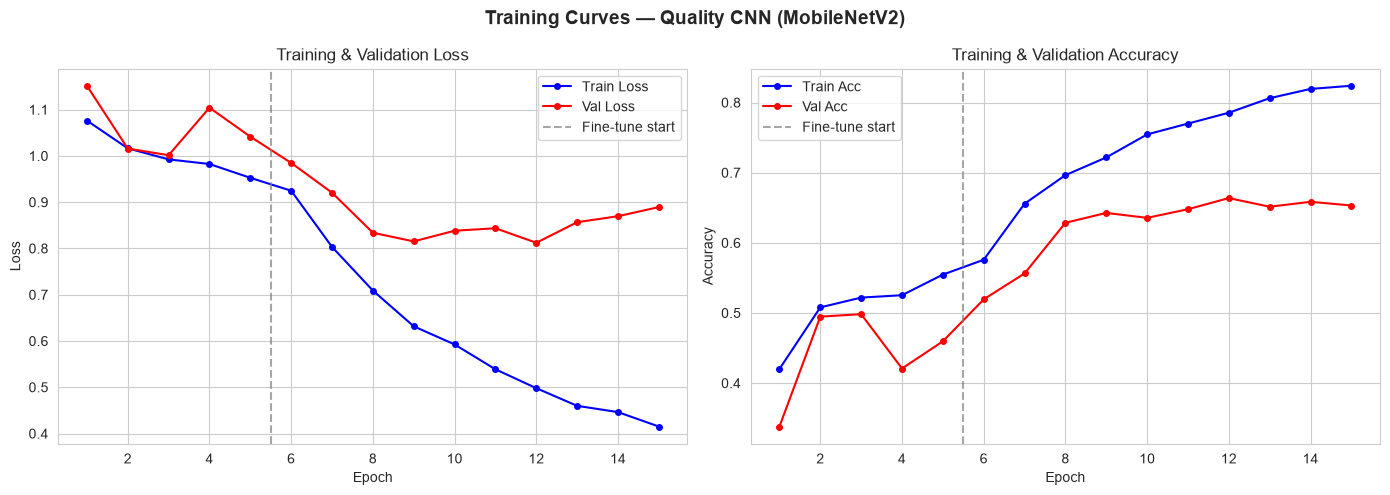

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)
phase_boundary = EPOCHS_FROZEN + 0.5

# Loss
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
ax1.axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

# Accuracy
ax2.plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
ax2.plot(epochs, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
ax2.axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()

plt.suptitle('Training Curves — Quality CNN (MobileNetV2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_training_curves.png', bbox_inches='tight')
plt.show()

## 4. Avaliação no Test Set

In [8]:
# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pth', weights_only=True, map_location=device))
model.eval()

test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Collect probabilities for ROC
all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        all_probs.append(probs.cpu().numpy())
all_probs = np.concatenate(all_probs)

Test Accuracy: 0.7040
Test Loss: 0.7392


In [9]:
# Classification Report
target_names = [IDX_TO_LABEL[i] for i in range(3)]
report = classification_report(all_labels, all_preds, target_names=target_names)
print('Classification Report:')
print(report)

Classification Report:
              precision    recall  f1-score   support

       ready       0.62      0.76      0.68       104
    marginal       0.58      0.64      0.61       174
   not_ready       0.84      0.72      0.78       293

    accuracy                           0.70       571
   macro avg       0.68      0.71      0.69       571
weighted avg       0.72      0.70      0.71       571



## 5. Confusion Matrix

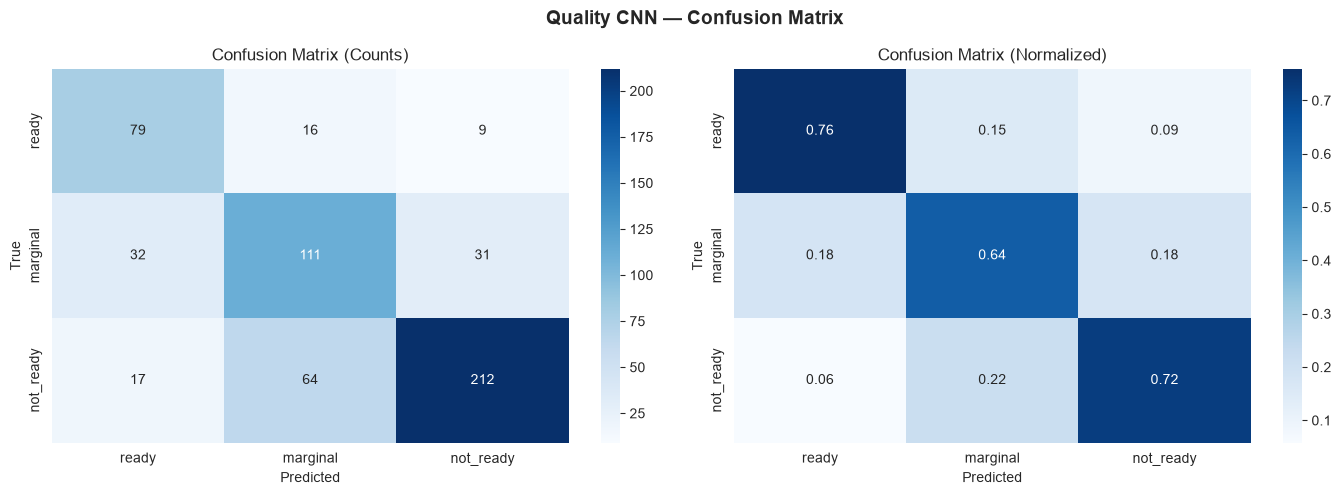

In [10]:
cm = confusion_matrix(all_labels, all_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names,
            yticklabels=target_names, ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names,
            yticklabels=target_names, ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix (Normalized)')

plt.suptitle('Quality CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 6. ROC Curve (Multiclass)

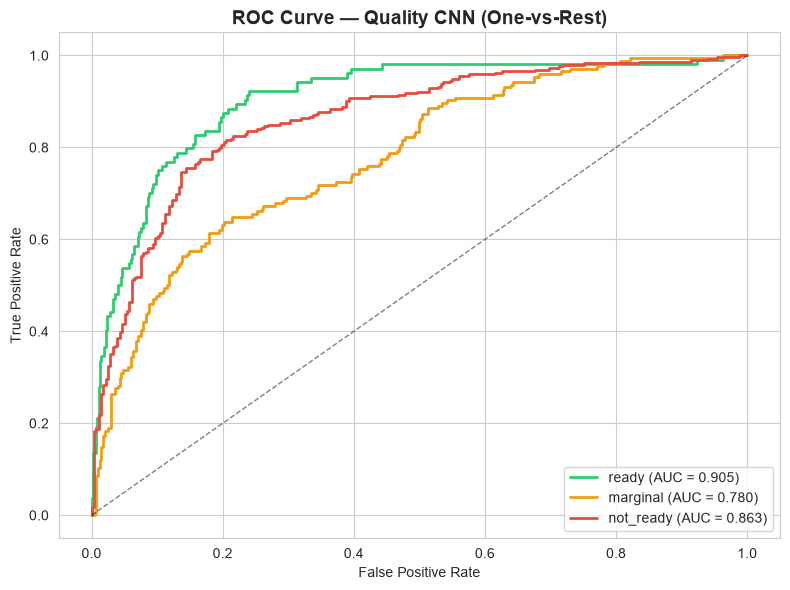

In [11]:
# Binarize labels for multiclass ROC
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (name, color) in enumerate(zip(target_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Quality CNN (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_roc_curve.png', bbox_inches='tight')
plt.show()

## 7. Distribuição de Scores por Classe

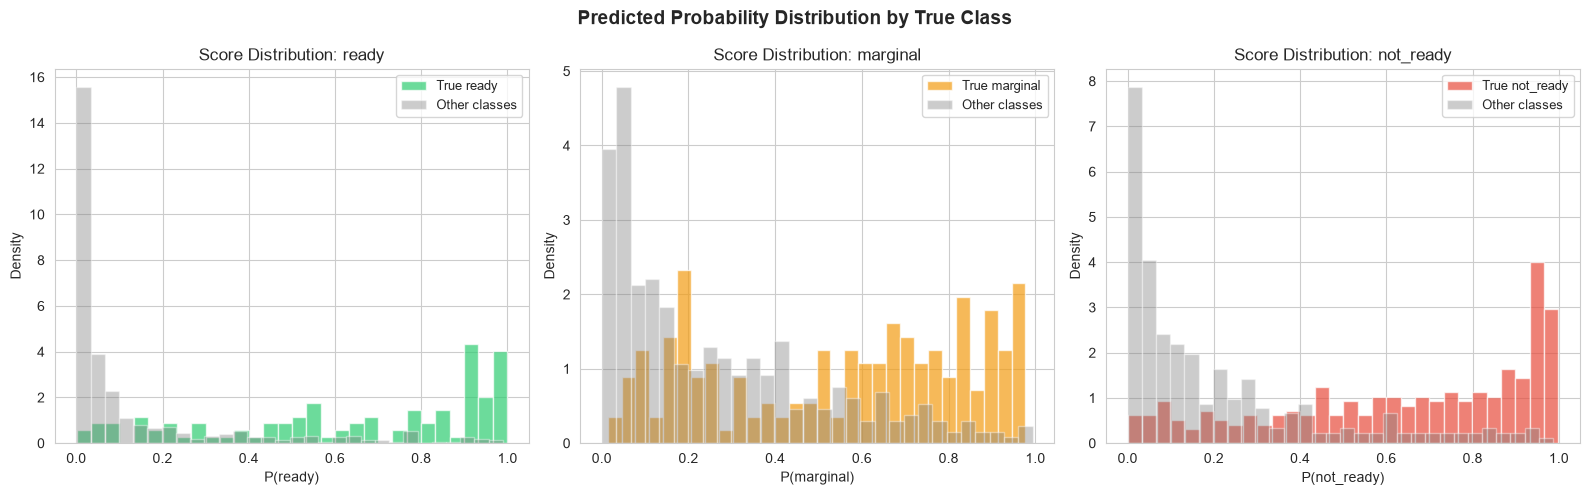

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (name, color) in enumerate(zip(target_names, colors)):
    ax = axes[i]
    # Scores for true class i
    mask = all_labels == i
    scores_correct = all_probs[mask, i]
    scores_wrong = all_probs[~mask, i]
    
    ax.hist(scores_correct, bins=30, alpha=0.7, color=color, label=f'True {name}', density=True)
    ax.hist(scores_wrong, bins=30, alpha=0.4, color='gray', label=f'Other classes', density=True)
    ax.set_xlabel(f'P({name})')
    ax.set_ylabel('Density')
    ax.set_title(f'Score Distribution: {name}')
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distribution by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_score_distribution.png', bbox_inches='tight')
plt.show()

## 8. Scatter: CNN Score vs CER

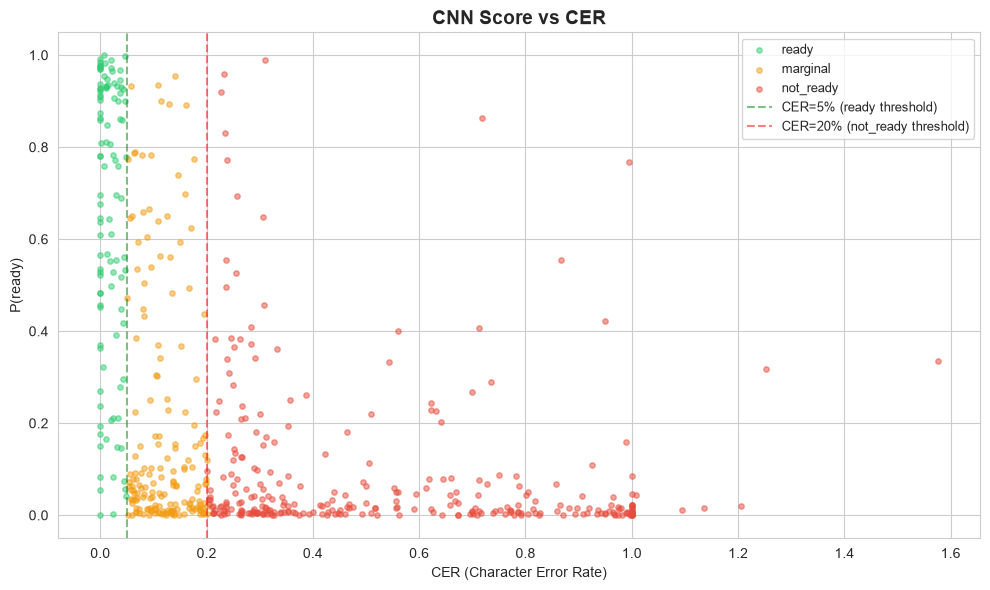

In [13]:
# Load CER values from test set samples
test_cer = [entry['cer'] for entry in test_ds.samples]
test_pred_ready_prob = all_probs[:, 0]  # P(ready)

fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
for i, name in enumerate(target_names):
    mask = all_labels == i
    ax.scatter(np.array(test_cer)[mask], test_pred_ready_prob[mask],
              alpha=0.5, s=15, c=colors_map[i], label=name)

ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.5, label='CER=5% (ready threshold)')
ax.axvline(x=0.20, color='red', linestyle='--', alpha=0.5, label='CER=20% (not_ready threshold)')
ax.set_xlabel('CER (Character Error Rate)')
ax.set_ylabel('P(ready)')
ax.set_title('CNN Score vs CER', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'quality_score_vs_cer.png', bbox_inches='tight')
plt.show()

## 9. Salvar Artefatos

In [14]:
# Save training history
history['test_acc'] = float(test_acc)
history['test_loss'] = float(test_loss)
history['classification_report'] = classification_report(
    all_labels, all_preds, target_names=target_names, output_dict=True
)
history['confusion_matrix'] = cm.tolist()

with open(OUTPUT_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

# Save final model
torch.save(model.state_dict(), OUTPUT_DIR / 'final_model.pth')

print(f'Best val accuracy: {best_val_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Artifacts saved to {OUTPUT_DIR}/')
print('\nFigures saved:')
for f in sorted((RESULTS_DIR / 'figures').glob('quality_*.png')):
    print(f'  {f.name}')

Best val accuracy: 0.6637
Test accuracy: 0.7040
Artifacts saved to ../models/quality_cnn/

Figures saved:
  quality_confusion_matrix.png
  quality_label_distribution.png
  quality_roc_curve.png
  quality_score_distribution.png
  quality_score_vs_cer.png
  quality_training_curves.png
